In [1]:
import csv
import numpy as np


from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import StratifiedKFold, KFold

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [2]:
filename='Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

data=[]
label=[]
header=[]

csv_file=open(filename)
csv_reader=csv.reader(csv_file)

header = next(csv_reader)
j=0
for row in csv_reader:
    j=j+1
    if (j%10) == 0:
        data.append(row[0:-2])

        if row[-1]=='BENIGN':
            label.append(0)
        else:
            label.append(1)

In [3]:
data_mat=np.array(data).astype(np.float64)
label_mat=np.array(label)

print(data_mat.shape)

(22573, 77)


# Using cross validation to estimate generalization error and its variance of Ada-Boost

In [4]:
#################################################################################################################
## Initializing the splitting and the performance lists
#################################################################################################################

kf = KFold(n_splits=10, shuffle=True)


Pr=np.zeros(10)
Rc=np.zeros(10)
F1=np.zeros(10)

#################################################################################################################
## Iterating through the folds
#################################################################################################################

for count, (train, test) in enumerate(kf.split(data_mat)):

    X_train = data_mat[train,:]
    X_test = data_mat[test,:]
    Y_train = label_mat[train]
    Y_test =  label_mat[test]
    
    clf = AdaBoostClassifier(n_estimators=10, random_state=0)
    clf.fit(X_train, Y_train)
    Y_hat=clf.predict(X_test)

    Pr[count] = precision_score(Y_test,Y_hat)

    Rc[count] = recall_score(Y_test,Y_hat)

    F1[count] = f1_score(Y_test,Y_hat)
    

 Mean Precision: 1.00 
 Standard deviation of Precision: 0.00


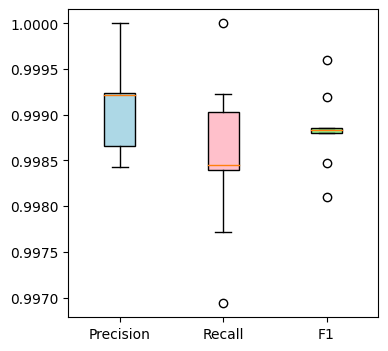

In [5]:
#################################################################################################################
## Printing mean and standard deviation of the precision score
#################################################################################################################
Pr_mean=np.mean(Pr)
Pr_std=np.std(Pr)

print(' Mean Precision: {:.2f} \n Standard deviation of Precision: {:.2f}'.format(Pr_mean, Pr_std))


fig  = plt.figure(figsize=(4, 4))
bplot1 = plt.boxplot([Pr, Rc, F1],
                         vert=True,  # vertical box alignment
                         patch_artist=True,  # fill with color
                         labels=['Precision','Recall','F1'])  # will be used to label x-ticks

#################################################################################################################
## Plotting boxplots for the scores
#################################################################################################################

colors = ['lightblue', 'pink', 'lightgreen']
for patch, color in zip(bplot1['boxes'], colors):
    patch.set_facecolor(color)
        
plt.show()

# Using cross validation to estimate generalization error and its variance of KNN classifier

In [6]:
#################################################################################################################
## Iterating through the folds
#################################################################################################################

Pr_knn=np.zeros(10)
Rc_knn=np.zeros(10)
F1_knn=np.zeros(10)

for j, (train, test) in enumerate(kf.split(data_mat, label_mat)):
    X_train = data_mat[train,:]
    X_test = data_mat[test,:]
    Y_train = label_mat[train]
    Y_test =  label_mat[test]
    
    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_train, Y_train)
    Y_hat=clf.predict(X_test)

    Pr_knn[j] = precision_score(Y_test,Y_hat)

    Rc_knn[j] = recall_score(Y_test,Y_hat)

    F1_knn[j] = f1_score(Y_test,Y_hat)


 Mean Precision: 0.99 
 Standard deviation of Precision: 0.00


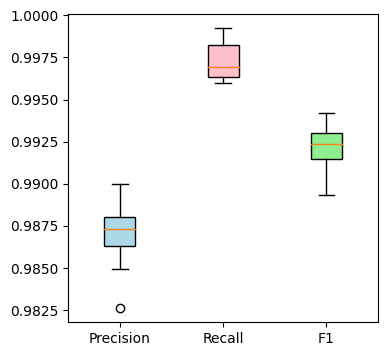

In [7]:
#################################################################################################################
## Printing mean and standard deviation of the precision score
#################################################################################################################
Pr_mean=np.mean(Pr_knn)
Pr_std=np.std(Pr_knn)

print(' Mean Precision: {:.2f} \n Standard deviation of Precision: {:.2f}'.format(Pr_mean, Pr_std))

#################################################################################################################
## Plotting boxplots for the scores
#################################################################################################################

fig  = plt.figure(figsize=(4, 4))
bplot1 = plt.boxplot([Pr_knn, Rc_knn, F1_knn],
                         vert=True,  # vertical box alignment
                         patch_artist=True,  # fill with color
                         labels=['Precision','Recall','F1'])  # will be used to label x-ticks

colors = ['lightblue', 'pink', 'lightgreen']
for patch, color in zip(bplot1['boxes'], colors):
    patch.set_facecolor(color)
        
plt.show()

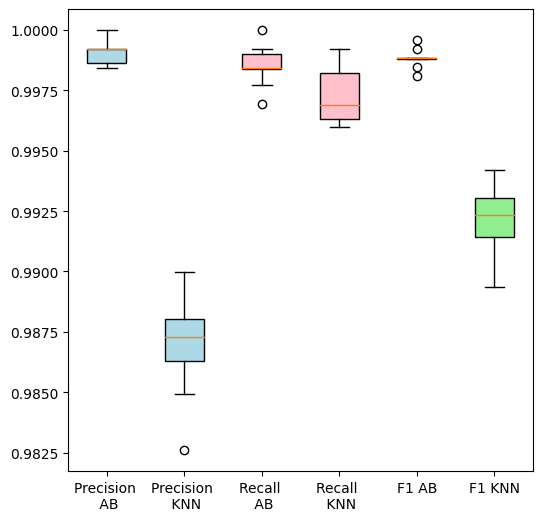

In [8]:
#################################################################################################################
## Comparing boxplots between AdaBoost and KNN
#################################################################################################################

fig  = plt.figure(figsize=(6, 6))
bplot1 = plt.boxplot([Pr, Pr_knn, Rc, Rc_knn, F1, F1_knn],
                         vert=True,  # vertical box alignment
                         patch_artist=True,  # fill with color
                         labels=['Precision \n AB', 'Precision \n KNN', 'Recall \n AB' , 'Recall \n KNN','F1 AB', 'F1 KNN'])  # will be used to label x-ticks

colors = ['lightblue', 'lightblue', 'pink', 'pink', 'lightgreen' , 'lightgreen']
for patch, color in zip(bplot1['boxes'], colors):
    patch.set_facecolor(color)
        
plt.show()

# Using KFolds with stratification

In [9]:
#################################################################################################################
## Initializing the splitting and the performance lists
#################################################################################################################

kf = StratifiedKFold(n_splits=10,shuffle=True)


Pr=np.zeros(10)
Rc=np.zeros(10)
F1=np.zeros(10)

#################################################################################################################
## Iterating through the folds
#################################################################################################################

for count, (train, test) in enumerate(kf.split(data_mat, label_mat)):

    X_train = data_mat[train,:]
    X_test = data_mat[test,:]
    Y_train = label_mat[train]
    Y_test =  label_mat[test]
    
    clf = AdaBoostClassifier(n_estimators=1, random_state=0)
    clf.fit(X_train, Y_train)
    Y_hat=clf.predict(X_test)

    Pr[count] = precision_score(Y_test,Y_hat)

    Rc[count] = recall_score(Y_test,Y_hat)

    F1[count] = f1_score(Y_test,Y_hat)

   ## Cross validating the choice of K
   

In [10]:
Pr=np.array([])
Rc=np.array([])
F1=np.array([])
Acc=np.array([])

Pr_s=np.array([])
Rc_s=np.array([])
F1_s=np.array([])
Acc_s=np.array([])

for n in range(20):
    
    Pr_knn=np.zeros(10)
    Rc_knn=np.zeros(10)
    F1_knn=np.zeros(10)
    Acc_knn=np.zeros(10)

    for j, (train, test) in enumerate(kf.split(data_mat, label_mat)):
        X_train = data_mat[train,:]
        X_test = data_mat[test,:]
        Y_train = label_mat[train]
        Y_test =  label_mat[test]

        clf = KNeighborsClassifier(n_neighbors=n+1)
        clf.fit(X_train, Y_train)
        Y_hat=clf.predict(X_test)

        Pr_knn[j] = precision_score(Y_test,Y_hat)

        Rc_knn[j] = recall_score(Y_test,Y_hat)

        F1_knn[j] = f1_score(Y_test,Y_hat)
        
        Acc_knn[j] = accuracy_score(Y_test,Y_hat)
    
 
    ## Computing mean and standard deviation of validation performance 
    Pr = np.append(Pr,np.mean(Pr_knn))
    Rc = np.append(Rc,np.mean(Rc_knn))
    F1 = np.append(F1,np.mean(F1_knn))
    Acc = np.append(Acc,np.mean(Acc_knn))
    
    Pr_s = np.append(Pr_s,np.std(Pr_knn))
    Rc_s = np.append(Rc_s,np.std(Rc_knn))
    F1_s = np.append(F1_s,np.std(F1_knn))
    Acc_s = np.append(Acc_s,np.std(Acc_knn))

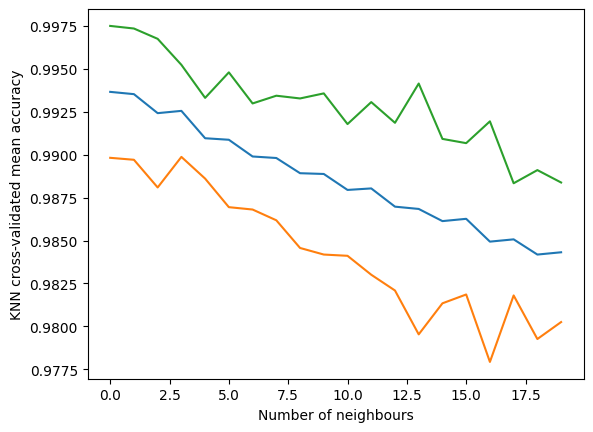

In [11]:
plt.plot(np.arange(20),Acc)
plt.plot(np.arange(20),Acc-2*Acc_s)
plt.plot(np.arange(20),Acc+2*Acc_s)

plt.xlabel('Number of neighbours')
plt.ylabel('KNN cross-validated mean accuracy')
plt.show()